In [1]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_dataset.xlsx to ecommerce_dataset.xlsx


In [4]:
import pandas as pd

df = pd.read_excel("ecommerce_dataset.xlsx")
df.head()

,Order ID,Customer ID,Order Date,Product,Quantity,Price,Region
0,ORD0001,CUST012,2023-08-19,Headphones,3,42731,North
1,ORD0002,CUST040,2023-12-05,Headphones,2,8501,South
2,ORD0003,CUST022,2023-05-02,Keyboard,4,42714,North
3,ORD0004,CUST027,2023-04-14,Headphones,5,1352,South
4,ORD0005,CUST026,2023-08-10,Printer,4,30113,South


In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order ID     120 non-null    object        
 1   Customer ID  120 non-null    object        
 2   Order Date   120 non-null    datetime64[ns]
 3   Product      120 non-null    object        
 4   Quantity     120 non-null    int64         
 5   Price        120 non-null    int64         
 6   Region       120 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 6.7+ KB


,0
Order ID,0
Customer ID,0
Order Date,0
Product,0
Quantity,0
Price,0
Region,0


**DATA CLEANING:**

```
# This is formatted as code
```



1. REMOVE DUPLICATES:

In [7]:
df = df.drop_duplicates()

2. FIX DATA TYPES:

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

3. CREATE REVENUE COLUMN:

In [9]:
df['Revenue'] = df['Quantity'] * df['Price']

4. Extract Month (important for trend)

In [10]:
df['Month'] = df['Order Date'].dt.to_period('M')

**EDA: EXPLORATORY DATA ANALYSIS**

In [11]:
df['Revenue'].sum()

np.int64(8850242)

In [12]:
df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Product,
Tablet,1495010
Monitor,1463345
Phone,1272865
Laptop,1182552
Keyboard,907287
Printer,905921
Headphones,840650
Mouse,782612


In [13]:
df.groupby('Region')['Revenue'].sum()

,Revenue
Region,
East,3166245
North,1809836
South,1928990
West,1945171


In [14]:
df.groupby('Month')['Revenue'].sum()

,Revenue
Month,
2023-01,801788
2023-02,445484
2023-03,1081501
2023-04,974643
2023-05,513811
2023-06,1057660
2023-07,454215
2023-08,685847
2023-09,553373


**VISUALIZATION:**

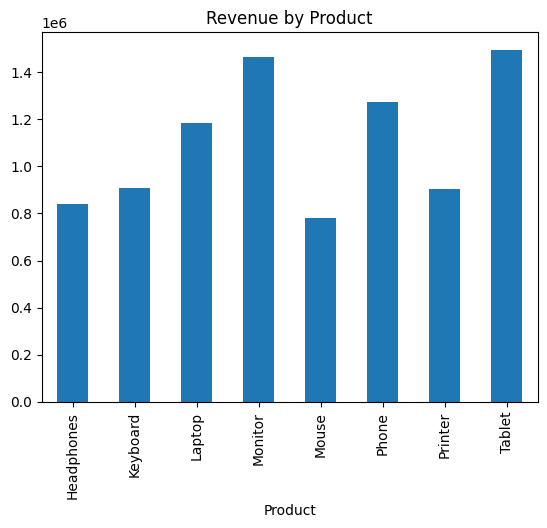

In [16]:
import matplotlib.pyplot as plt

# Top products
df.groupby('Product')['Revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product")
plt.show()

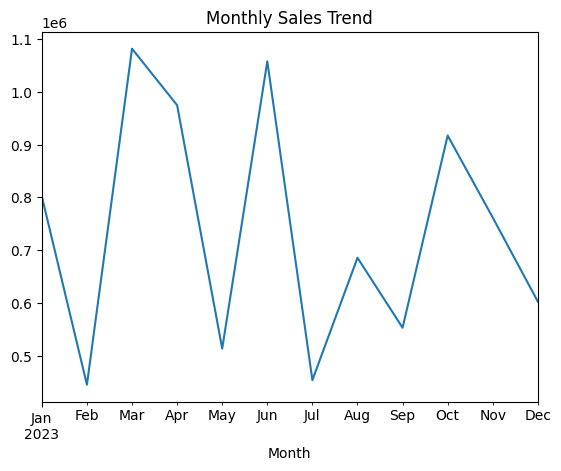

In [17]:
# Monthly trend
df.groupby('Month')['Revenue'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [18]:
df.to_csv("cleaned_data.csv", index=False)

In [19]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>